# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local news reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly pip nbformat

Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('data/Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('data/Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('data/Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('data/Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('data/Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
print(df_hh_income.shape)
print(df_hh_income.columns.tolist())
print(df_hh_income.head())

(29322, 3)
['Geographic Area', 'City', 'Median Income']
  Geographic Area             City Median Income
0              AL       Abanda CDP         11207
1              AL   Abbeville city         25615
2              AL  Adamsville city         42575
3              AL     Addison town         37083
4              AL       Akron town         21667


In [6]:
print(df_pct_poverty.shape)
print(df_pct_poverty.columns.tolist())
print(df_pct_poverty.head())

(29329, 3)
['Geographic Area', 'City', 'poverty_rate']
  Geographic Area             City poverty_rate
0              AL       Abanda CDP         78.8
1              AL   Abbeville city         29.1
2              AL  Adamsville city         25.5
3              AL     Addison town         30.7
4              AL       Akron town           42


In [7]:
print(df_pct_completed_hs.shape)
print(df_pct_completed_hs.columns.tolist())
print(df_pct_completed_hs.head())

(29329, 3)
['Geographic Area', 'City', 'percent_completed_hs']
  Geographic Area             City percent_completed_hs
0              AL       Abanda CDP                 21.2
1              AL   Abbeville city                 69.1
2              AL  Adamsville city                 78.9
3              AL     Addison town                 81.4
4              AL       Akron town                 68.6


In [8]:
print(df_share_race_city.shape)
print(df_share_race_city.columns.tolist())
print(df_share_race_city.head())

(29268, 7)
['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
  Geographic area             City share_white share_black  \
0              AL       Abanda CDP        67.2        30.2   
1              AL   Abbeville city        54.4        41.4   
2              AL  Adamsville city        52.3        44.9   
3              AL     Addison town        99.1         0.1   
4              AL       Akron town        13.2        86.5   

  share_native_american share_asian share_hispanic  
0                     0           0            1.6  
1                   0.1           1            3.1  
2                   0.5         0.3            2.3  
3                     0         0.1            0.4  
4                     0           0            0.3  


In [9]:
print(df_fatalities.shape)
print(df_fatalities.columns.tolist())
print(df_fatalities.head())

(2535, 14)
['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera']
   id                name      date   manner_of_death       armed   age  \
0   3          Tim Elliot  02/01/15              shot         gun 53.00   
1   4    Lewis Lee Lembke  02/01/15              shot         gun 47.00   
2   5  John Paul Quintero  03/01/15  shot and Tasered     unarmed 23.00   
3   8     Matthew Hoffman  04/01/15              shot  toy weapon 32.00   
4   9   Michael Rodriguez  04/01/15              shot    nail gun 39.00   

  gender race           city state  signs_of_mental_illness threat_level  \
0      M    A        Shelton    WA                     True       attack   
1      M    W          Aloha    OR                    False       attack   
2      M    H        Wichita    KS                    False        other   
3      M    W  San Francisco    CA                     True       attack   

## Data Cleaning - Check for Missing Values and Duplicates

Dealing with the NaN values. Perhaps substituting 0 is appropriate.

In [10]:
for name, df in [("hh_income", df_hh_income), ("pct_poverty", df_pct_poverty),
                 ("pct_completed_hs", df_pct_completed_hs), ("share_race_city", df_share_race_city),
                 ("fatalities", df_fatalities)]:
    print(f"\n--- {name} ---")
    print("NaNs:\n", df.isna().sum())
    print("Duplicates:", df.duplicated().sum())


--- hh_income ---
NaNs:
 Geographic Area     0
City                0
Median Income      51
dtype: int64
Duplicates: 0

--- pct_poverty ---
NaNs:
 Geographic Area    0
City               0
poverty_rate       0
dtype: int64
Duplicates: 0

--- pct_completed_hs ---
NaNs:
 Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64
Duplicates: 0

--- share_race_city ---
NaNs:
 Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64
Duplicates: 0

--- fatalities ---
NaNs:
 id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_le

In [11]:
print(df_fatalities["race"].unique())

['A' 'W' 'H' 'B' 'O' nan 'N']


In [12]:
# Fix inconsistent colmn name
df_share_race_city.rename(columns={'Geographic area': 'Geographic Area'}, inplace=True)

# Fill NaNs - modern pandas style
df_hh_income["Median Income"] = df_hh_income["Median Income"].fillna(0)
df_fatalities["armed"] = df_fatalities["armed"].fillna("Unknown")
df_fatalities["race"] = df_fatalities["race"].fillna("Unknown")
df_fatalities["flee"] = df_fatalities["flee"].fillna("Unknown")

# Fix types
df_fatalities["age"] = df_fatalities["age"].astype("Int64")
df_fatalities["date"] = pd.to_datetime(df_fatalities["date"], format="%d/%m/%y")

# Map race abbreviations
race_map = {"A": "Asian", "W": "White", "H": "Hispanic", "B": "Black", "N": "Native American", "O": "Other", "Unknown": "Unknown"}
df_fatalities["race"] = df_fatalities["race"].map(race_map)

print(df_fatalities.dtypes)
print(df_fatalities.head())

id                                  int64
name                               object
date                       datetime64[ns]
manner_of_death                    object
armed                              object
age                                 Int64
gender                             object
race                               object
city                               object
state                              object
signs_of_mental_illness              bool
threat_level                       object
flee                               object
body_camera                          bool
dtype: object
   id                name       date   manner_of_death       armed  age  \
0   3          Tim Elliot 2015-01-02              shot         gun   53   
1   4    Lewis Lee Lembke 2015-01-02              shot         gun   47   
2   5  John Paul Quintero 2015-01-03  shot and Tasered     unarmed   23   
3   8     Matthew Hoffman 2015-01-04              shot  toy weapon   32   
4   9   Michael Rodrigu

# Poverty Rate in each US State

A bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate? Bar Plot

In [13]:
df_pct_poverty["poverty_rate"] = pd.to_numeric(df_pct_poverty["poverty_rate"], errors="coerce")
poverty_by_state = df_pct_poverty.groupby("Geographic Area")["poverty_rate"].mean().reset_index()
poverty_by_state.sort_values("poverty_rate", ascending=False, inplace=True)

fig = px.bar(poverty_by_state,
             x="Geographic Area",
             y="poverty_rate",
             title="Poverty Rate by US State")
fig.show()

## Poverty Rate by US State

The bar chart ranks all US states by their average poverty rate from highest to lowest.

**Key Findings:**
- **Mississippi (MS)** has the highest poverty rate at ~26.8%, followed closely by **Arizona (AZ)** at ~25.6%
- **New Jersey (NJ)**, **Connecticut (CT)**, and **Massachusetts (MA)** have the lowest poverty rates, all under 10%
- There is a significant gap between the poorest and wealthiest states, with nearly a 3x difference between MS and NJ
- Southern states (MS, AR, LA, SC, GA) dominate the high-poverty end of the chart
- Northeastern states tend to cluster at the lower end of the poverty spectrum

# High School Graduation Rate by US State

High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [15]:
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')
hs_by_state = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().reset_index()
hs_by_state.sort_values('percent_completed_hs', ascending=True, inplace=True)

fig = px.bar(hs_by_state,
             x='Geographic Area',
             y='percent_completed_hs',
             title='High School Graduation Rate by US State')
fig.show()

## High School Graduation Rate by US State

The bar chart ranks all US states by their average high school graduation rate in ascending order.

**Key Findings:**
- **Texas (TX)** and **Mississippi (MS)** have the lowest high school graduation rates at ~75-78%
- **Massachusetts (MA)**, **Wyoming (WY)**, and **Hawaii (HI)** have the highest rates, approaching ~92%
- The overall range is relatively narrow (75-90%) compared to poverty rates, suggesting education access is more evenly distributed across states
- Southern states (TX, MS, GA, LA, AR) cluster at the bottom, mirroring their high poverty rates — a pattern worth exploring further
- This chart already hints at an inverse relationship between poverty and education

# Visualize the Relationship between Poverty Rates and High School Graduation Rates

#### A line chart with two y-axes to show if the rations of poverty and high school graduation move together.

In [17]:
poverty_sorted = poverty_by_state.sort_values('Geographic Area')
hs_sorted = hs_by_state.sort_values('Geographic Area')

fig = px.line(title='Poverty Rate vs High School Graduation Rate by State')

fig.add_scatter(x=poverty_sorted['Geographic Area'],
                y=poverty_sorted['poverty_rate'],
                name='Poverty Rate')

fig.add_scatter(x=hs_sorted['Geographic Area'],
                y=hs_sorted['percent_completed_hs'],
                name='HS Graduation Rate',
                yaxis='y2')

fig.update_layout(
    yaxis=dict(title='Poverty Rate'),
    yaxis2=dict(title='HS Graduation Rate', overlaying='y', side='right')
)

fig.show()

## Poverty Rate vs High School Graduation Rate by State

A dual y-axis line chart comparing poverty rates and high school graduation rates across all US states, sorted alphabetically.

**Key Findings:**
- An inverse relationship is visible — states with higher poverty rates tend to have lower high school graduation rates
- The two lines generally move in opposite directions, confirming that poverty and education are closely linked
- Mississippi (MS) is a standout — high poverty spike coincides with a dip in graduation rate
- The relationship is not perfect, some states like Hawaii (HI) show high graduation rates despite moderate poverty
- This suggests poverty is a strong but not sole driver of educational outcomes

#### Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualize the same relationship

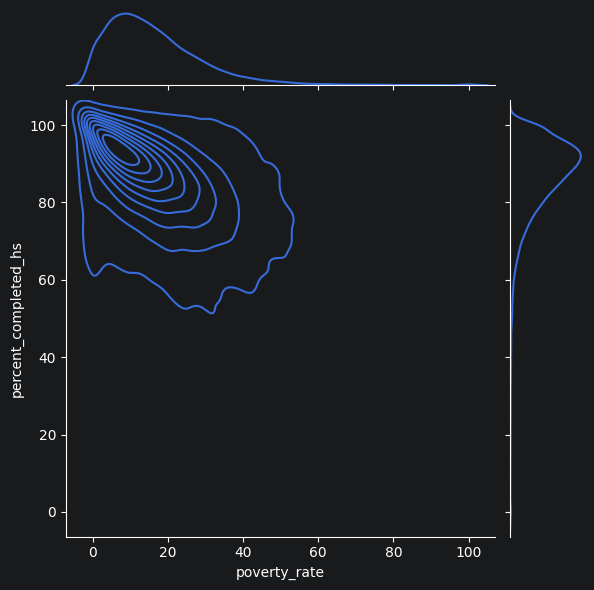

In [18]:
merged_poverty_hs = pd.merge(df_pct_poverty, df_pct_completed_hs, on=['Geographic Area', 'City'])

sns.jointplot(x='poverty_rate',
              y='percent_completed_hs',
              data=merged_poverty_hs,
              kind='kde')
plt.show()

## Jointplot: Poverty Rate vs High School Graduation Rate (City Level)

A KDE jointplot showing the density of the relationship between poverty rate and high school graduation rate at the city level.

**Key Findings:**
- The densest cluster sits in the top-left — low poverty (0-20%) and high graduation rates (80-100%)
- The contours stretch toward the bottom-right, confirming the inverse relationship
- The marginal distributions show poverty is right-skewed — most cities have low poverty rates
- HS graduation is left-skewed — most cities have high graduation rates
- The relationship holds at city level, reinforcing the state-level findings from the line chart

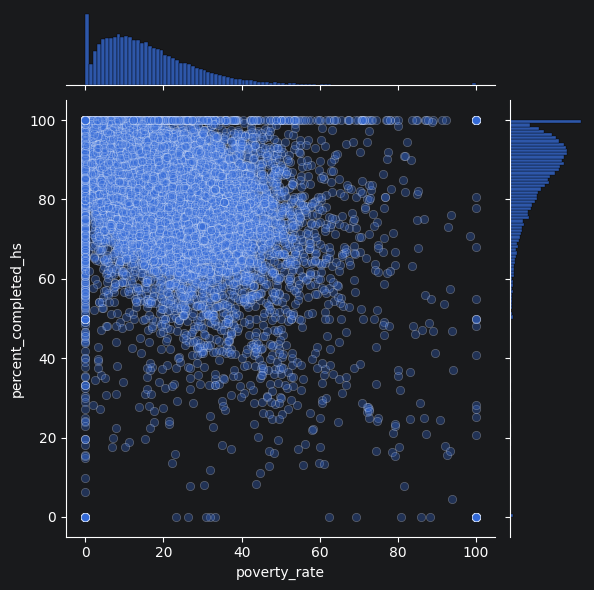

In [19]:
sns.jointplot(x='poverty_rate',
              y='percent_completed_hs',
              data=merged_poverty_hs,
              kind='scatter',
              alpha=0.3)
plt.show()

## Scatter Plot: Poverty Rate vs High School Graduation Rate (City Level)

A scatter jointplot showing individual city-level data points for poverty rate vs high school graduation rate.

**Key Findings:**
- The bulk of cities cluster in the top-left — low poverty and high graduation rates
- As poverty rate increases, the density of points shifts downward, confirming the inverse relationship
- Notable outliers exist at 0% and 100% on both axes, likely data quality issues in the census data
- The marginal histograms confirm both distributions are skewed — most cities have low poverty and high graduation rates
- The scatter adds granularity to the KDE, showing the wide spread of graduation rates even at similar poverty levels

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

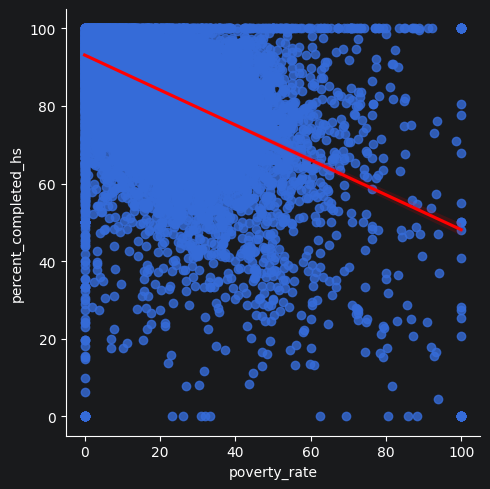

In [20]:
sns.lmplot(x='poverty_rate',
           y='percent_completed_hs',
           data=merged_poverty_hs,
           line_kws={'color': 'red'})
plt.show()

## LM Plot: Linear Regression - Poverty Rate vs High School Graduation Rate

A linear regression plot showing the relationship between poverty rate and high school graduation rate at the city level.

**Key Findings:**
- The red regression line has a clear negative slope, statistically confirming the inverse relationship
- For every increase in poverty rate, high school graduation rate tends to decrease
- The wide spread of points around the line indicates significant variance — poverty explains part of the story but not all of it
- Cities with very low poverty still show a wide range of graduation rates, suggesting other socioeconomic factors are at play
- The outliers at 0% and 100% (data source issue) skew the regression slightly but the overall trend remains strong

# Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualize the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

In [24]:
race_cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
for col in race_cols:
    df_share_race_city[col] = pd.to_numeric(df_share_race_city[col], errors='coerce')

race_by_state = df_share_race_city.groupby('Geographic Area')[race_cols].mean().reset_index()

fig = px.bar(race_by_state,
             x='Geographic Area',
             y=race_cols,
             title='Racial Makeup by US State',
             barmode='stack',
             labels={'value': 'Population (%)', 'variable': 'Race'})
fig.show()

## Racial Makeup by US State

A stacked bar chart showing the average racial composition by US state using census data.

**Key Findings:**
- White population dominates the majority of states, particularly in the Midwest and Northeast
- Black population share is notably higher in Southern states like MS, LA, and SC
- Hispanic population is largest in NM, TX, and CA
- Hawaii (HI) stands out with a significantly lower white share and higher Asian population
- Native American population is most visible in NM and AK

**Data Note:** Some states exceed 100% due to overlapping racial categories. Others like Hawaii fall short of 100% because the 5 racial categories tracked here do not fully capture all demographic groups — notably Native Hawaiian/Pacific Islander which is absent from this dataset.

# Donut Chart of People Killed by Race

Use `.value_counts()`

In [25]:
race_counts = df_fatalities['race'].value_counts()

fig = px.pie(values=race_counts.values,
             names=race_counts.index,
             title='People Killed by Police by Race',
             hole=0.4)
fig.show()

## People Killed by Police by Race

A donut chart showing the breakdown of police fatalities by race.

**Key Findings:**
- White victims represent the largest group in raw numbers at 47.4%, followed by Black at 24.4% and Hispanic at 16.7%
- However, raw numbers are misleading without context — White Americans make up ~60% of the US population, meaning they are actually underrepresented in fatalities relative to population size
- Black Americans make up ~13% of the US population but account for 24.4% of fatalities — nearly double their population share, indicating significant overrepresentation
- Hispanic Americans at 16.7% fatalities are roughly proportional to their ~18% population share
- 7.69% of fatalities have unknown race, which is a data gap worth noting

# Chart Comparing the Total Number of Deaths of Men and Women

`df_fatalities` illustrates how many more men are killed compared to women.

In [26]:
gender_counts = df_fatalities['gender'].value_counts()

fig = px.bar(x=gender_counts.index,
             y=gender_counts.values,
             title='People Killed by Police by Gender',
             labels={'x': 'Gender', 'y': 'Number of Deaths'})
fig.show()

In [28]:
gender_pct = df_fatalities['gender'].value_counts(normalize=True) * 100

fig = px.pie(values=gender_pct.values,
             names=gender_pct.index,
             title='People Killed by Police by Gender (%)',
             hole=0.4)
fig.show()

## People Killed by Police by Gender

A bar chart comparing the total number of police fatalities between men and women.

**Key Findings:**
- Men account for 2,428 fatalities (95.8%) vs 107 women (4.2%) — an overwhelming disparity
- Men are nearly 23x more likely to be killed by police than women
- This could reflect higher rates of male involvement in violent crime, higher male presence in police encounters, or potential gender bias in use of force decisions
- The disparity is consistent with broader criminal justice data where men are disproportionately represented at every level — arrests, incarceration, and use of force

# Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

In [29]:
fig = px.box(df_fatalities,
             x='manner_of_death',
             y='age',
             color='gender',
             title='Age and Manner of Death by Gender')
fig.show()

## Age and Manner of Death by Gender

A box plot breaking down the age distribution of police fatalities by manner of death and gender.

**Key Findings:**
- There are only two manners of death in the dataset — shot, and shot and Tasered
- The median age for both genders across both manners of death is around 35-40 years old
- Women killed by shot have a slightly higher median age than men
- The "shot and Tasered" category shows a tighter age distribution for both genders, with fewer outliers
- Men show more outliers on the older end, particularly in the shot category, with some victims in their 80s and one in their 90s
- Overall there is no dramatic difference between genders in terms of age or manner of death

# Were People Armed? 

In what percentage of police killings were people armed? A chart showing what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed?

In [30]:
armed_counts = df_fatalities['armed'].value_counts()

fig = px.bar(x=armed_counts.index,
             y=armed_counts.values,
             title='Weapons Carried by People Killed by Police',
             labels={'x': 'Weapon', 'y': 'Number of Deaths'})
fig.show()

In [31]:
# Top 10 weapons
top_armed = armed_counts.head(10)

fig = px.bar(x=top_armed.index,
             y=top_armed.values,
             title='Top 10 Weapons Carried by People Killed by Police',
             labels={'x': 'Weapon', 'y': 'Number of Deaths'})
fig.show()

# Unarmed percentage
unarmed_pct = (df_fatalities['armed'] == 'unarmed').sum() / len(df_fatalities) * 100
print(f'Percentage unarmed: {unarmed_pct:.2f}%')

Percentage unarmed: 6.75%


## Weapons Carried by People Killed by Police

A bar chart showing the top 10 weapons reported on victims at the time of the fatal police encounter.

**Key Findings:**
- Gun is by far the most common weapon at 1,398 cases, followed distantly by knife at ~373
- 6.75% of people killed by police were completely unarmed — roughly 1 in 15
- "Undetermined" and "unknown weapon" appear in the top 10, highlighting inconsistent reporting
- Vehicle appears as the 3rd most common "weapon", likely reflecting fleeing suspects
- Toy weapon appears in the top 10 — these are cases where victims carried realistic-looking toy guns

**Data Quality Note:** The full weapons list contains highly questionable classifications including beer bottles, pens, air conditioners, fireworks, and motorcycles. Since this data is self-reported by police departments, it is inherently subjective and may reflect post-incident justification rather than objective reporting. This is a significant limitation when interpreting the data.

# How Old Were the People Killed?

Percentage of people killed were under 25 years old.

In [33]:
# Percentage under 25
under_25 = (df_fatalities['age'] < 25).sum() / df_fatalities['age'].count() * 100
print(f'Percentage under 25: {under_25:.2f}%')

Percentage under 25: 18.31%


Histogram and KDE plot that shows the distribution of ages of the people killed by police.

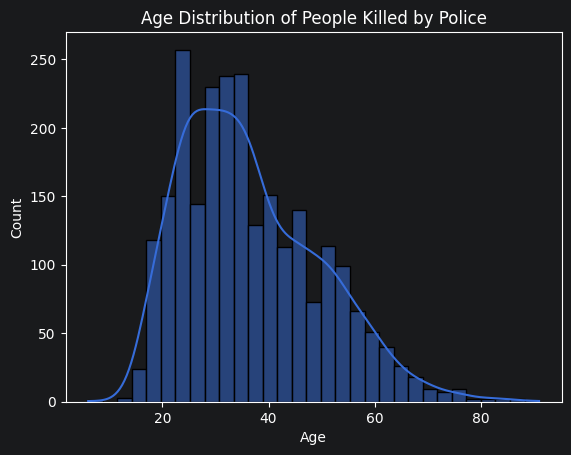

In [34]:
# Histogram + KDE
fig, ax = plt.subplots()
sns.histplot(df_fatalities['age'].dropna(), kde=True, ax=ax)
ax.set_title('Age Distribution of People Killed by Police')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
plt.show()

## Age Distribution of People Killed by Police

18.31% of people killed by police were under 25 years old — nearly 1 in 5.

**Key Findings:**
- The distribution is right-skewed, peaking between ages 25-35
- The most common age of victims is in the late 20s to early 30s
- Deaths drop off sharply after age 50 but do occur into the 80s
- 18.31% under 25 is significant — young people are disproportionately represented
- The KDE curve confirms the concentration of fatalities in the younger adult population

Separate KDE plot for each race. Is there a difference between the distributions?

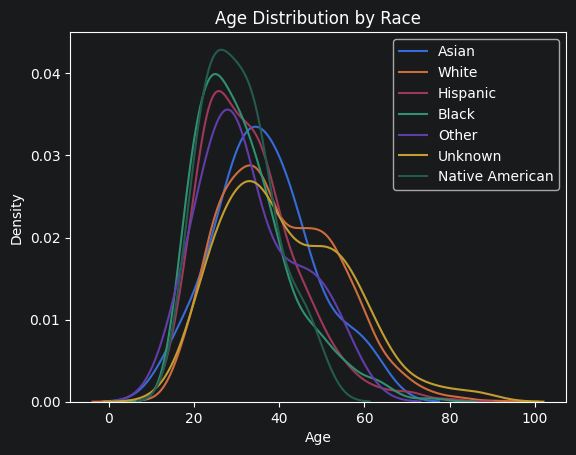

In [35]:
for race in df_fatalities['race'].dropna().unique():
    subset = df_fatalities[df_fatalities['race'] == race]['age'].dropna()
    sns.kdeplot(subset, label=race)

plt.title('Age Distribution by Race')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

## Age Distribution by Race — KDE Plot

A kernel density estimate showing the age distribution of police fatalities broken out by race.

**Key Findings:**
- Black and Hispanic victims skew significantly younger, with peaks around age 25 — suggesting younger individuals of these groups are disproportionately at risk
- White victims have a flatter, wider distribution peaking around age 35-40, indicating fatalities are more spread across age groups
- Asian victims show a broader distribution, peaking latest of all groups around age 30-35
- Native American victims show a sharp, narrow peak around age 25-30
- The younger peak for Black victims is particularly striking and consistent with broader systemic disparities in policing of younger Black men

# Race of People Killed

Chart that shows the total number of people killed by race.

In [36]:
race_counts = df_fatalities['race'].value_counts()

fig = px.bar(x=race_counts.index,
             y=race_counts.values,
             title='Total Number of People Killed by Police by Race',
             labels={'x': 'Race', 'y': 'Number of Deaths'})
fig.show()

## Total Number of People Killed by Police by Race

A bar chart showing the raw count of police fatalities by race.

**Key Findings:**
- White victims have the highest raw count at 1,201, followed by Black at 618 and Hispanic at 423
- However, as noted earlier, raw numbers without population context are misleading
- Black Americans are killed at roughly half the rate of White Americans in raw numbers, yet represent only ~13% of the population vs ~60% — meaning their per-capita rate is disproportionately higher
- The Unknown category at 195 represents a meaningful data gap that could shift these numbers
- Asian and Native American fatalities are low in raw numbers but Native Americans are significantly overrepresented relative to their ~1.3% population share

# Mental Illness and Police Killings

Percentage of people killed by police have been diagnosed with a mental illness.

In [37]:
mental_illness_pct = df_fatalities['signs_of_mental_illness'].sum() / len(df_fatalities) * 100
print(f'Percentage with signs of mental illness: {mental_illness_pct:.2f}%')

Percentage with signs of mental illness: 24.97%


In [38]:
mental_illness_counts = df_fatalities['signs_of_mental_illness'].value_counts()

fig = px.pie(values=mental_illness_counts.values,
             names=['No Mental Illness', 'Mental Illness'],
             title='People Killed by Police - Signs of Mental Illness',
             hole=0.4)
fig.show()

## Mental Illness and Police Killings

~25% of people killed by police showed signs of mental illness — roughly 1 in 4.

**Key Findings:**
- 24.97% of fatalities involved individuals showing signs of mental illness at the time of the encounter
- This raises serious questions about police training and preparedness for mental health crisis situations
- Mental health crisis calls are fundamentally different from criminal encounters yet are often handled by armed officers with little to no mental health training
- Many advocates argue that mental health professionals, not armed police, should be the first responders in mental health crisis situations
- The ~25% figure is likely an undercount as mental illness is often undiagnosed or unreported in police incident reports

# Cities where the Most Police Killings Take Place?

Chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?

In [39]:
top_cities = df_fatalities['city'].value_counts().head(10)

fig = px.bar(x=top_cities.index,
             y=top_cities.values,
             title='Top 10 Cities with Most Police Killings',
             labels={'x': 'City', 'y': 'Number of Deaths'})
fig.show()

## Top 10 Cities with Most Police Killings

A bar chart ranking the 10 cities with the highest number of police fatalities.

**Key Findings:**
- Los Angeles leads with 39 killings, followed by Phoenix 31 and Houston 27
- Chicago 25 and Las Vegas 21 round out the top 5
- Importantly, most of these are among the largest cities in the US by population — higher population naturally means more police encounters
- Raw numbers without per-capita adjustment can be misleading — a city like St. Louis with 15 killings but a much smaller population may actually have a higher per-capita rate than Los Angeles
- The presence of Sun Belt cities like Phoenix, Houston, San Antonio, and Austin suggests regional patterns worth investigating further

# Rate of Death by Race

The share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city.

In [40]:
top_10_cities = df_fatalities['city'].value_counts().head(10).index.tolist()

fatalities_top10 = df_fatalities[df_fatalities['city'].isin(top_10_cities)]

race_by_city = fatalities_top10.groupby(['city', 'race']).size().reset_index(name='killings')

fig = px.bar(race_by_city,
             x='city',
             y='killings',
             color='race',
             title='Police Killings by Race in Top 10 Cities',
             barmode='group')
fig.show()

## Police Killings by Race in Top 10 Cities

A grouped bar chart showing the racial breakdown of police killings in the 10 cities with the most fatalities.

**Key Findings:**
- Chicago stands out dramatically — Black victims (21) vastly outnumber all other races, reflecting the city's deep racial disparities in policing
- Los Angeles has the highest Hispanic fatality count (19) of any city, consistent with its large Hispanic population
- St. Louis shows an overwhelming Black majority in fatalities despite being a mid-sized city, suggesting severe racial disparities
- Phoenix and Austin skew more White and Hispanic in fatalities, reflecting their demographic makeup
- Houston shows Black victims (15) significantly outnumbering Hispanic (6) and White (3), following the same pattern of Black overrepresentation seen in other cities
- Miami shows a relatively balanced split between Black and Hispanic victims
- These patterns suggest that local demographics and policing practices vary significantly by city

# Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare map with previous chart. Are these the same states with high degrees of poverty?

In [41]:
killings_by_state = df_fatalities['state'].value_counts().reset_index()
killings_by_state.columns = ['state', 'killings']

fig = px.choropleth(killings_by_state,
                    locations='state',
                    locationmode='USA-states',
                    color='killings',
                    scope='usa',
                    title='Police Killings by US State')
fig.show()

## Police Killings by US State — Choropleth Map

A choropleth map showing the total number of police killings by state.

**Key Findings:**
- California is by far the center of attention with 424 killings, driven largely by Los Angeles and its massive population
- Texas and Florida follow as the next highest states, again reflecting population size
- Arizona and Oklahoma stand out as mid-sized states with disproportionately high killing counts relative to their population
- Northeastern states and upper Midwest show the lowest counts, consistent with lower population density and different policing cultures
- Comparing with the poverty map, Mississippi and Louisiana have high poverty but relatively lower killing counts — suggesting poverty alone does not predict police killings
- The pattern largely mirrors population distribution rather than poverty rates, unlike what one might initially assume

# Number of Police Killings Over Time

Number of Police Killings over Time. Is there a trend in the data?

In [43]:
killings_by_date = df_fatalities.groupby(df_fatalities['date'].dt.year)['id'].count().reset_index()
killings_by_date.columns = ['year', 'killings']
killings_by_date['year'] = killings_by_date['year'].astype(str)

fig = px.line(killings_by_date,
              x='year',
              y='killings',
              title='Police Killings Over Time')
fig.show()

## Killings by Year — Line Chart

A Line Chart showing the total number of police killings Year Over Year.

**Key Findings:**
- The 2017 drop is misleading. The dataset does not cover the full year of 2017 (through July).
- The decline appears as sharp when it's really just incomplete data.
- Only 3 years is not much of a trend.
- More granular (by month) chart would tell us more.

In [44]:
killings_by_month = df_fatalities.groupby(df_fatalities['date'].dt.to_period('M'))['id'].count().reset_index()
killings_by_month.columns = ['month', 'killings']
killings_by_month['month'] = killings_by_month['month'].astype(str)

fig = px.line(killings_by_month,
              x='month',
              y='killings',
              title='Police Killings Over Time (Monthly)')
fig.show()

## Police Killings Over Time

Annual and monthly breakdown of police killings from January 2015 to mid-2017.

**Key Findings:**
- The annual chart shows an apparent decline from 2015 to 2017, but this is misleading — 2017 data is incomplete, cutting off mid-year
- The monthly chart tells the real story — killings remain remarkably consistent, hovering between 65-104 per month
- There is no meaningful downward trend despite increased public scrutiny and protests following high-profile cases in 2015-2016
- A notable spike occurs around June/July 2015 (up to 104 killings) and around December/February 2017 (up to 100 killings)
- The consistency of the monthly numbers suggests systemic factors rather than isolated incidents — roughly 80 people are killed by police every month in the US
- With only 2.5 years of data it is difficult to draw long-term conclusions about trends

In [45]:
df_fatalities['year'] = df_fatalities['date'].dt.year
df_fatalities['month'] = df_fatalities['date'].dt.month

killings_by_year_month = df_fatalities.groupby(['year', 'month'])['id'].count().reset_index()
killings_by_year_month.columns = ['year', 'month', 'killings']
killings_by_year_month['year'] = killings_by_year_month['year'].astype(str)

fig = px.line(killings_by_year_month,
              x='month',
              y='killings',
              color='year',
              title='Police Killings by Month per Year',
              labels={'month': 'Month', 'killings': 'Number of Killings'})
fig.update_xaxes(tickmode='array',
                 tickvals=list(range(1, 13)),
                 ticktext=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
fig.show()

## Police Killings by Month per Year

A multi-line chart comparing monthly killings across 2015, 2016, and 2017.

**Key Findings:**
- All three years consistently hover between 70-105 killings per month — no drastic reduction year over year
- 2015 shows a dramatic June/July spike (104), the highest period in the dataset
- 2016 is the most stable year with the least variance month to month
- 2017 data cuts off at July, confirming the incomplete year flagged earlier
- Summer months (June-July) tend to spike across all years, possibly linked to increased outdoor activity and police encounters in warmer months
- The flatness across years is perhaps the most sobering finding — despite massive public pressure and protests following high-profile killings, the monthly rate remained virtually unchanged

# Epilogue

Now that the analysis of the data is done, let's read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).

# Epilogue — Comparing Our Findings with The Washington Post

The Washington Post has been tracking fatal police shootings since 2015, ultimately recording over 10,000 fatalities through 2024. Here is how our findings compare:

## ✅ Where We Agreed

**Racial Disparity**
Our analysis identified Black Americans as significantly overrepresented in fatalities relative to their ~13% population share. The WaPo confirms this with hard per-capita numbers — Black Americans are killed at 6.0 per million per year vs 2.3 per million for White Americans, more than twice the rate.

**Age Distribution**
We found the peak age range to be 25-35. WaPo confirms that more than half of victims are between 20-40 years old, with 25-34 being the most represented age group.

**Gender**
We found 95.8% of victims were male. WaPo confirms over 95% are male — an almost exact match.

## 🔍 Where WaPo Goes Further

**Scale and Trend**
Our dataset only covered 2015-2017 (~2,500 fatalities). WaPo's full decade of data reveals over 10,000 killings and a worrying upward trend — 2024 was the deadliest year on record at 1,175 killings. Our limited data showed no clear trend, which makes sense given how short our window was.

**Underreporting**
A critical finding we couldn't detect from our data — WaPo discovered that FBI reported numbers undercount actual police killings by more than half, because local departments are not required to report to the federal government. This means the true scale of the problem is likely far larger than any dataset captures.

**Per-Capita Rate**
WaPo adjusts for population size, revealing the true disparity. Our raw numbers showed White victims as the largest group — WaPo's per-capita analysis flips the narrative entirely, showing Black Americans face more than 2.5x the risk of White Americans when population is accounted for.

## 📌 Key Takeaway
Our analysis, despite being limited to 2.5 years of data, reached conclusions consistent with WaPo's decade-long investigation. The racial disparity, age concentration, and gender skew all aligned. What our analysis lacked was the per-capita adjustment and the longer time horizon needed to detect the troubling upward trend in killings that WaPo uncovered.